# Import libs

In [11]:
from regime_identification.Features.features import get_log
from regime_identification.Features.regimes import expanding_norm, get_pca, scree_pca, plot_clusters
from regime_identification.Data.yf_tickers import load_prices

import pandas as pd
import numpy as np
from datetime import datetime, timedelta, date
import yaml

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm # Loading bars

In [12]:
# Ignore performance warnings from pandas
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

# Data retrieval

In [18]:
processed_dir = "../Data/Processed"

config = yaml.safe_load(open("config.yml"))
etfs = load_prices(f"{processed_dir}/ETFs/")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:00<00:00, 31.27it/s]


## Best and worst performers per phase

We can rate the per-regime performance of asset classes via the next-day-closing returns of a representative ETF. 

There are many metrics to rate stock performance by, such as raw returns or sharpe ratio. Here, stocks are **rated by sortino ratio**, where returns are penalized for their **downside volatility only** (as opposed to bidirectional volatility with sharpe ratio). This is done in the interest of minimizing risk for leveraged positions. 

Note that the worst performers should have the lowest upside volatility instead (hence the altered "inverse" sortino formula used).

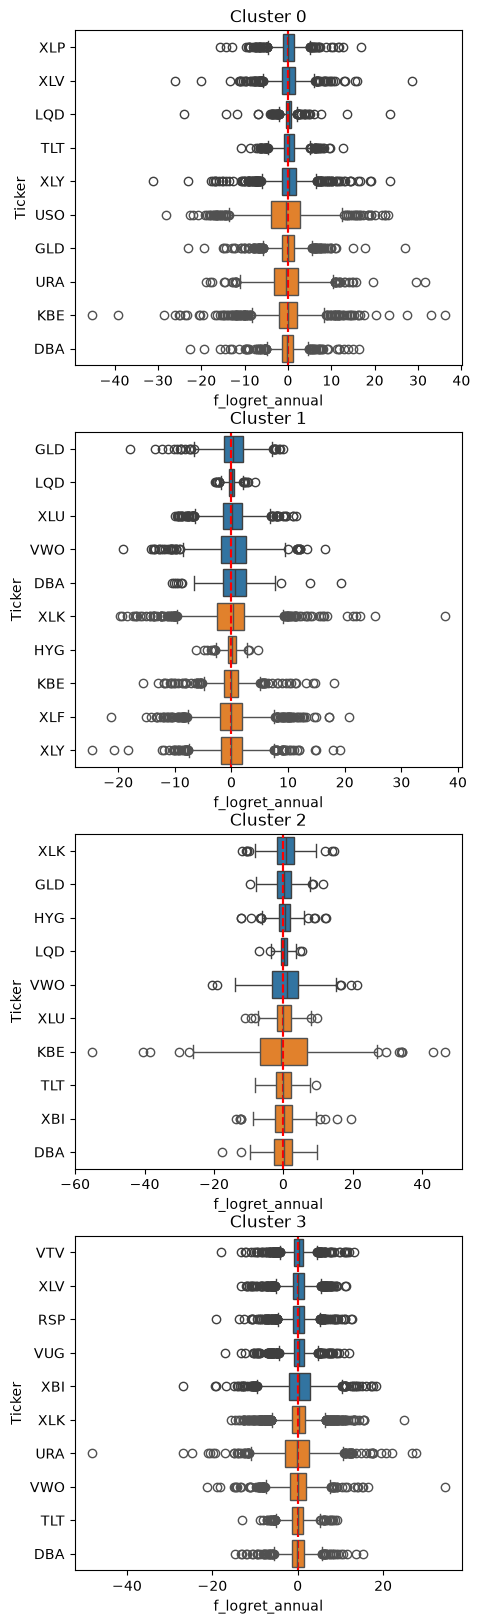

In [15]:
# Plot performance
n_clusters = config["N_CLUSTERS"]
n_tickers = 5 # How many tickers to display for each side
axis = 0

fig, ax = plt.subplots(n_clusters, 1, figsize = (5, 20))

df = pd.concat(etfs.values()) # values() to avoid redundant multiindex

# Don't show VIX, as it is not an asset class
df = df[df["Ticker"] != "^VIX"]

'''
axis = 0
for i in ["training", "test"]:
    sns.boxplot(data = df[df["set"] == i].reset_index(), x = 'f_1d_Close_logret', y = "Ticker", 
                hue = "cluster", # orient = "v",
                ax = ax[axis],
               ).set_title(i)
    ax[axis].set_xlim(-0.10, 0.10)
    ax[axis].axvline(x = 0, color = "red", linestyle = "--")
    axis += 1
    
'''

best_tickers = {}
worst_tickers = {}
for i in range(n_clusters):
    # Again, only use training data to evaluate performance pre-testing
    best_tickers_sortino = df[(df["cluster"] == i) & (df["set"] == "training")].groupby("Ticker")["f_logret_annual"].apply(lambda x: np.sum(x) / np.std(x[x < 0])).nlargest(n_tickers, keep = "first").index 
    best_tickers_sortino = list(best_tickers_sortino)
    best_tickers[i] = best_tickers_sortino

    worst_tickers_sortino = df[(df["cluster"] == i) & (df["set"] == "training")].groupby("Ticker")["f_logret_annual"].apply(lambda x: -np.sum(x) / np.std(x[x > 0])).nlargest(n_tickers, keep = "first").index 
    worst_tickers_sortino = list(worst_tickers_sortino)
    worst_tickers[i] = worst_tickers_sortino

    for j in [best_tickers_sortino, worst_tickers_sortino]:
        sns.boxplot(data = df[(df["cluster"] == i) & (df["set"] == "training") & (df["Ticker"].isin(j))].reset_index(), x = 'f_logret_annual', y = "Ticker", 
                    # hue = "set", # orient = "v",
                    ax = ax[axis],
                   ).set_title(f"Cluster {i}")
        # ax[axis].set_xlim(-1, 1)
        ax[axis].axvline(x = 0, color = "red", linestyle = "--")

    
    axis += 1
        
plt.show()
plt.close()

# Statistical testing

Note that <u>**all of statistical tests are only performed on training data!**</u> We want to establish a "realistic" strategy based on data available in 2019 to backtest later.

alpha p < 0.10 is chosen as significant. This is high in relation to traditional p-values. The justification is that less-significant differences in return distributions may still provide economically relevant results. This is also the reason I will not be adjusting for the multiple comparisons problem of testing many asset classes.

In [19]:
alpha = config["ALPHA"]

## Between regimes

### Expected returns

To estimate the expected return for each asset class in each regime (and wether it differs meaningfully from zero) we make use of a **simple OLS linear regression** model. Note that **returns are logarithmic and annualized**.

In [20]:
import statsmodels.formula.api as smf

In [21]:
# Between-regime expected returns testing
def br_er_test(etfs, set_ = "training", alpha = 0.10, only_sig = False):
    print("Significant OLS linear regression results:")
    
    for ticker, df in etfs.items():
        if set_ is not None: df = df[df["set"] == set_] # Test only on training data!
        df["cluster"] = df["cluster"].astype("category")
    
        x_cols = ["cluster", ]
        y_col = ["f_logret_annual"] # List for ease-of-use. Should be one var.

        df = df[x_cols + y_col].dropna(how = "any") # remove all NAs
    
        x = df[x_cols]
        y = df[y_col] # Easier interpretation because of annualization

        # x = smf.add_constant(x) # Add intercept
    
        model = smf.ols(
            "f_logret_annual ~ C(cluster)",
            data = df
        ).fit()

        p_values = model.pvalues
        p_under_alpha = p_values[p_values < alpha]
        params = model.params # .loc[list(set(p_values.index).add("Intercept"))]
        if not only_sig: 
            result_df = pd.DataFrame([p_values, params], index = ["p", "param"]).T
            print(f"{ticker}: \n{result_df}\n")
        elif not p_under_alpha.empty:
            result_df = pd.DataFrame([p_under_alpha, params], index = ["p", "param"]).T
            print(f"{ticker}: \n{result_df}\n")
        else:
            print(f"No significant results for {ticker}")

In [22]:
br_er_test(etfs, set_ = "training", alpha = alpha, only_sig = False)

Significant OLS linear regression results:
XLP: 
                          p     param
Intercept          0.112211  0.102203
C(cluster)[T.1.0]  0.402607 -0.076784
C(cluster)[T.2.0]  0.917487 -0.019213
C(cluster)[T.3.0]  0.429573 -0.065139

VTV: 
                        p     param
Intercept        0.880216  0.012941
C(cluster)[T.1]  0.899450  0.018339
C(cluster)[T.2]  0.677164  0.097705
C(cluster)[T.3]  0.308486  0.114589

XLK: 
                          p     param
Intercept          0.322799  0.108435
C(cluster)[T.1.0]  0.215256 -0.193795
C(cluster)[T.2.0]  0.474817  0.225917
C(cluster)[T.3.0]  0.690526 -0.055961

USO: 
                        p     param
Intercept        0.000015 -0.701828
C(cluster)[T.1]  0.008414  0.783600
C(cluster)[T.2]  0.088007  0.724213
C(cluster)[T.3]  0.000053  0.869842

GLD: 
                        p     param
Intercept        0.345219 -0.081183
C(cluster)[T.1]  0.016658  0.343835
C(cluster)[T.2]  0.277208  0.251184
C(cluster)[T.3]  0.125180  0.174968

XL

**IMPORTANT**: "Intercept" (I) here is regime 0, used as a baseline, and each slope (T) is for subsequent regimes.

Thus expected return (E) for each regime can be calculated as:<br> <u>E(0) = I; E(1) = I + T1; E(2) = I + T2; ..</u>

We can see that **several asset classes have returns significantly higher/lower than 0 dependent on the regime**. 
The most important results per regime are:

- Most assets seem to be **in turmoil in regime 0** (E < -17%). Notable **exceptions** are both **government bonds** (TLT) and **corporate bonds** (LQD). **US oil** (USO) is especially vulnerable to these downturns (E = -70%).
- **Regime 1** seems to indicate strong growth (E > 26%) periods for **gold** (GLD) and **agriculture** (DBA).
- **Emerging markets** (VWO) seem to grow strongly in **regime 2**.
- Besides **US oil performing well** (E = 17%), **regime 3** has the least interesting significant results

### Distributions

Differences in return distributions are informative as to how asset classes behave in certain regimes. As we cannot assume neither normal distributions nor heteroscedasticity, the use of a non-parametric test will give the most accurate results for comparing return distributions between and within asset classes and regimes. For this we use the **Kruskal-Wallis test**.

In [23]:
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn as dunn

In [24]:
# Between-regime distribution-differences test
def br_dist_test(etfs, set_ = "training", alpha = 0.10): 
    br_dfs = {} # Dict of between-regime cluster future returns
    for ticker, df in etfs.items():
        if set_ is not None: df = df[df["set"] == set_] # Use only training/test data!
        result = df.groupby("cluster")["f_logret"].apply(list).apply(pd.Series).T

        result.columns.name = None   

        br_dfs[ticker] = result

    print("\nKruskal-Wallis significant results:")
    sig_br = {} # Significant tickers
    for ticker, df in br_dfs.items():
        df_l = [list(df[c]) for c in df.columns] # Split needed for scipy API
        H_stat, p_stat = kruskal(*df_l, nan_policy = "omit")
        if p_stat < alpha:
            print(f"Ticker: {ticker}; H: {H_stat}; p: {p_stat}")
            sig_br[ticker] = df

    print("\nSignificant Dunn post-hoc results:")
    for ticker, df in sig_br.items():
        df_l = [list(df[c]) for c in df.columns] # Split needed for scipy API
        du = dunn(df_l, p_adjust = "bonferroni")
        print(f"Ticker: {ticker} \n{du[du < alpha]}\n")

In [25]:
br_dist_test(etfs, set_ = "training", alpha = alpha)


Kruskal-Wallis significant results:
Ticker: USO; H: 16.682633556313135; p: 0.0008212972417977688
Ticker: GLD; H: 9.921548309558895; p: 0.019244911129219115
Ticker: VWO; H: 7.874155099837058; p: 0.04868541359041003
Ticker: DBA; H: 12.71209059096825; p: 0.0053024597131813905

Significant Dunn post-hoc results:
Ticker: USO 
          1   2   3         4
1       NaN NaN NaN  0.000459
2       NaN NaN NaN       NaN
3       NaN NaN NaN       NaN
4  0.000459 NaN NaN       NaN

Ticker: GLD 
         1        2   3   4
1      NaN  0.01123 NaN NaN
2  0.01123      NaN NaN NaN
3      NaN      NaN NaN NaN
4      NaN      NaN NaN NaN

Ticker: VWO 
    1   2   3   4
1 NaN NaN NaN NaN
2 NaN NaN NaN NaN
3 NaN NaN NaN NaN
4 NaN NaN NaN NaN

Ticker: DBA 
          1         2   3         4
1       NaN  0.002812 NaN       NaN
2  0.002812       NaN NaN  0.072338
3       NaN       NaN NaN       NaN
4       NaN  0.072338 NaN       NaN



<u>**BEWARE NON-ZERO BASED INDEX IN DUNN POST-HOC!**</u> Subtract all indices by 1 to get the corresponding regime.

From the **Kruskal-Wallis results**, it seems **US oil, agriculture, emerging markets and gold** have significantly altered **return distributions** (p < 0.5) **depending on market regime**. However, **emerging markets lose their significance** in **post-hoc Dunn** testing.

These results can be used to confirm several observations in our previous expected return testing.

- **US oil** performs differently in regime 0 vs 3, consistent with their respective dismal and good expected returns.
- **Agriculture** returns are differently distributed in regime 1 vs 0 & 3. This strengthens previous observations of high DBA expected returns in regime 1.
- **Gold** similarly behaves differently in regime 1 vs 0, consistent with above-average expected return.

Other asset classes not showing significance in these tests does not mean we should discount previous results in OLS regression. Rather, we should **focus on gold, oil & agriculture** as our strongest/most consistent signals.

## Between asset classes

### Mean returns

Between asset classes, we are less interested in return distribution difference (as most asset classes have a "unique" distribution anyways). Instead, a **pure difference in mean returns** is more valuable information. A suitable test would be **Welch's ANOVA**. Beware we still violate the assumption of normal distribution!

In [26]:
from scipy.stats import f_oneway as anova
from scipy.stats import tukey_hsd

In [27]:
# Between asset classes mean returns differences test
def ba_mr_test(etfs, set_ = "training", alpha = alpha):
    ba_dfs = {} # Dict of per-regime between-asset future returns

    for cluster in range(n_clusters):
        ba_dfs[cluster] = pd.DataFrame()

    ###
    # TODO: Adapt to get ba_dfs directly from etfs
    ###
    br_dfs = {} # Dict of between-regime cluster future returns
    for ticker, df in etfs.items():
        if set_ is not None: df = df[df["set"] == set_] # Use only training data!
        result = df.groupby("cluster")["f_logret"].apply(list).apply(pd.Series).T

        result.columns.name = None   

        br_dfs[ticker] = result
        
    for ticker, df in br_dfs.items():
        for cluster in df.columns:
            ba_dfs[cluster][ticker] = df[cluster]

    print("Welch's ANOVA results:")
    sig_ba = {} # Significant tickers
    for cluster, df in ba_dfs.items():
        df_l = [list(df[t]) for t in df.columns] # Split needed for scipy API
        F_stat, p_stat = anova(*df_l, nan_policy = "omit", 
                               equal_var = False) # Specifically use Welch's ANOVA
        if p_stat < alpha:
            print(f"Cluster: {cluster}; H: {F_stat}; p: {p_stat}")
            sig_ba[cluster] = df

    print("Tukey's post-hoc results:")
    for cluster, df in sig_ba.items():
        print(pd.DataFrame(df.columns, list(range(len(df.columns)))))
        df_l = [list(df[t].dropna(how = "any")) for t in df.columns] # Split needed for scipy API
        result = tukey_hsd(*df_l, equal_var = False)
        print(result)

In [28]:
ba_mr_test(etfs, set_ = "training", alpha = alpha)

Welch's ANOVA results:
Cluster: 0; H: 1.7172933148534941; p: 0.01437523556933838
Tukey's post-hoc results:
      0
0   XLP
1   VTV
2   XLK
3   USO
4   GLD
5   XLV
6    VT
7   XLB
8   VNQ
9   URA
10  HYG
11  RSP
12  LQD
13  XLU
14  VUG
15  PHO
16  VWO
17  EMB
18  KBE
19  TLT
20  ITA
21  XBI
22  IWM
23  XLF
24  DBA
25  XLY



KeyboardInterrupt



Only **regime 0** (p = 0.013) seems to have significant differences in returns between asset classes. Because of the sheer amount of asset classes, it is doubtful that this will survive post-hoc multiple testing correction. 

From these results, it seems **USO** consistently has a significantly different mean from all other asset classes in **regime 0**. This tracks with our previous observation of **extreme turmoil for oil markets during regime 0** in between-regime testing! 

### Correlation

Another avenue for exploration is the use of asset correlations in different regimes. By identifying regime-specific uncorrelated assets, we can **optimize our portfolio's "free lunch" in diversification**.

A note on using Kendall rank correlation: 
We are interested in correlation as a metric of how similar price movements are, e.g. "does x go up when y does?". The relative size of price movements (used in Spearman rank correlation) is not as important as **the sign**, the concordance and discordance with regards to point (0, 0), which **is tested explicitly in Kendall rank correlation**. 

Furthermore, we are specifically interested in **UN**correlated assets. As such, we **look to accept H0: Tau = 0** during hypothesis testing!

In [29]:
from scipy.stats import kendalltau

In [30]:
# ETF correlation matrices per regime
def ba_corr(etfs, set_ = "training", n_clusters = n_clusters, alpha = alpha):
    corrM_d = {}
    sig_d = {}
    for cluster in range(n_clusters):
        logret_df = pd.DataFrame()
        for name, df in etfs.items():
            if set_ is not None: df = df[df["set"] == set_]
            logret_df[name] = df[df["cluster"] == cluster].loc[:, "f_logret"]
        
        # Kendall Tau statistical test  
        sig_d[cluster] = pd.DataFrame()
        ncols = len(logret_df.columns)
        for i in range(ncols): 
            col1 = logret_df.iloc[:, i]
            name1 = col1.name
            for j in range(ncols):
                col2 = logret_df.iloc[:, j]
                name2 = col2.name
                # print(i, name1, j, name2)

                tau, p = kendalltau(col1, col2)
                if p > alpha: # Note: We actually want to ACCEPT H0, as we are looking for UNCORRELATED assets!
                    sig_d[cluster].loc[name1, name2] = p
                else: 
                    sig_d[cluster].loc[name1, name2] = 0
            
        # Raw Kendall coefficients
        corrM = logret_df.corr(method = "kendall")
        corrM_d[cluster] = corrM

    return corrM_d, sig_d

In [31]:
training_corrM_d, training_sig_d = ba_corr(etfs, set_ = "training", n_clusters = n_clusters, alpha = alpha)

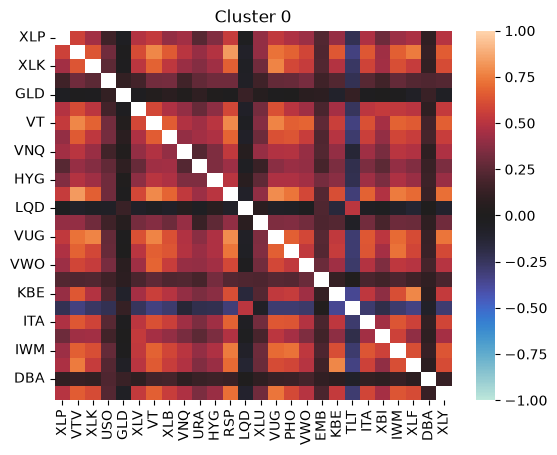

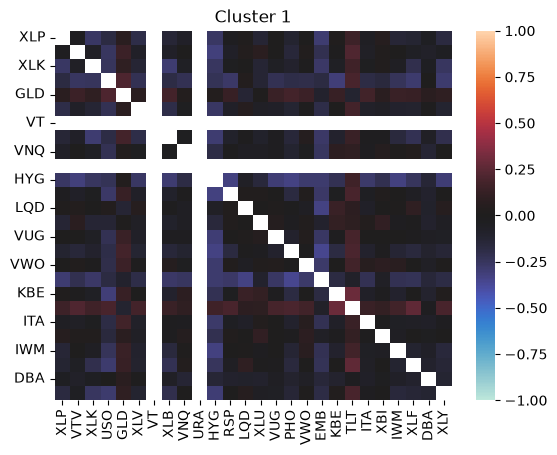

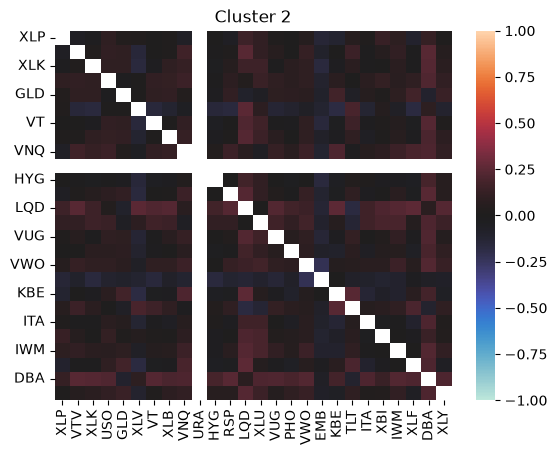

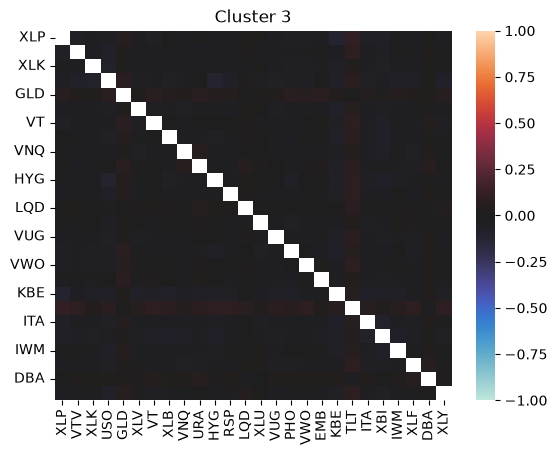

In [32]:
# Plotting correlations as heatmap
corr_threshold = 1 # Should be +, applied to both positive and negative values!; 1 for no threshold
ref_cluster = 0 # Cluster that serves as a "reference" for other periods; None for no ref
etf_slice = None # ETFs to slice out; None for no slice

if ref_cluster is not None: ref_df = training_corrM_d[ref_cluster]

for name, df in training_corrM_d.items():
    df_ = df[(df > -corr_threshold) & (df < corr_threshold)]

    if etf_slice:
        df_ = df_.loc[etf_slice, :]
    if (ref_cluster is not None) & (name is not ref_cluster):
        df_ = df_ - ref_df
        
    sns.heatmap(df_, vmin = -corr_threshold, vmax = corr_threshold, center = 0).set_title(f"Cluster {name}")
    plt.show()
    plt.close()

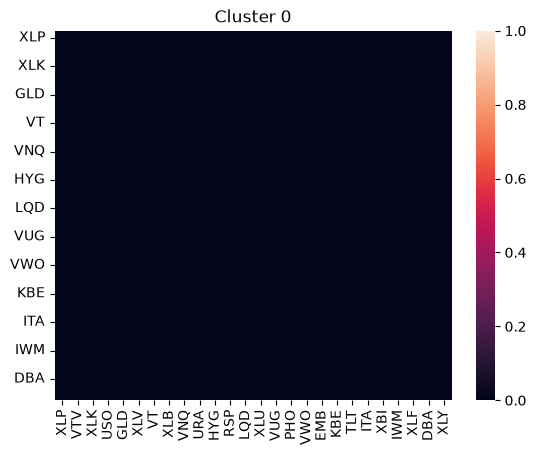

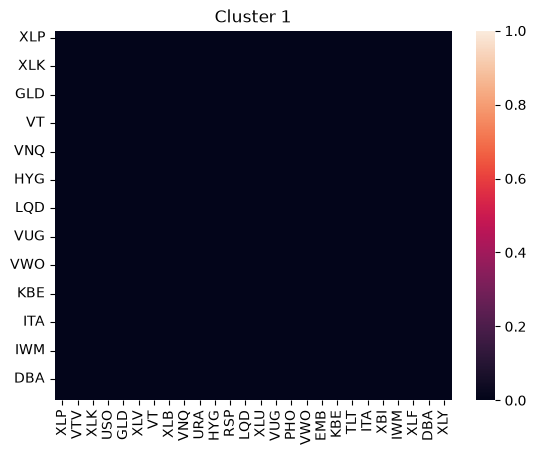

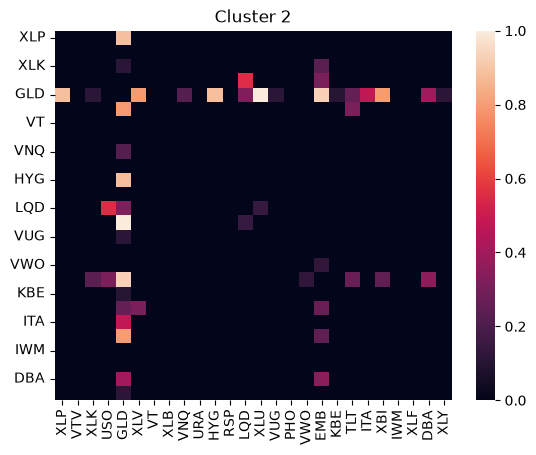

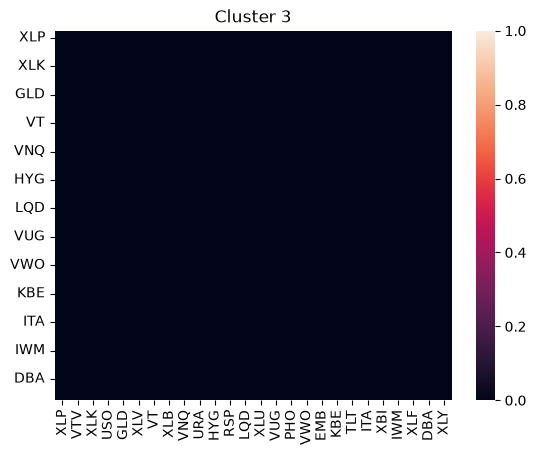

In [33]:
# Plotting significantly UNcorrelated asset classes (Accepted H0: Tau = 0)
for cluster, df in training_sig_d.items():
    # print(f"Cluster {cluster}:\n{df}\n")
    sns.heatmap(df, vmin = 0, vmax = 1).set_title(f"Cluster {cluster}")
    plt.show()
    plt.close()

From these correlation results, using **RSP** as our default benchmark:
- **Gold and corporate bonds are the most consistently uncorrelated** asset to our benchmark across regimes.
- **Regime 0 and 3** are similar in that **most asset classes show correlation**
- <u>**NO asset classes are SIGNIFICANTLY uncorrelated to RSP across any regimes!**</u>

This is a pretty disappointing result, as we cannot use the fan-favorite S&P500/RSP as our benchmark asset. Instead, we should look to make uncorrelated combinations of assets we have strong between-regime expected return results for. 

# Testing validation

As we did our analyses in the training dataset (pre-2019), we now want to validate the observations in unseen test data (post-2019). 

## Repeat statistical testing

We can repeat our same statistical tests to see if the stats held throughout the entire observational period and/or the test period by itself.

### Whole dataset

In [34]:
# Between regimes
## Distribution differences
br_dist_test(etfs, set_ = None, alpha = alpha)
## Return differences
br_er_test(etfs, set_ = None, alpha = alpha)

# Between asset classes
## Mean returns differences 
ba_mr_test(etfs, set_ = None, alpha = alpha)


Kruskal-Wallis significant results:
Ticker: USO; H: 26.405285681642983; p: 7.844249532810789e-06
Ticker: GLD; H: 14.222296415561148; p: 0.002617666225890937
Ticker: DBA; H: 13.657820695046414; p: 0.0034099282757600493

Significant Dunn post-hoc results:
Ticker: USO 
          1         2   3         4
1       NaN  0.000711 NaN  0.000004
2  0.000711       NaN NaN       NaN
3       NaN       NaN NaN       NaN
4  0.000004       NaN NaN       NaN

Ticker: GLD 
          1         2   3   4
1       NaN  0.001053 NaN NaN
2  0.001053       NaN NaN NaN
3       NaN       NaN NaN NaN
4       NaN       NaN NaN NaN

Ticker: DBA 
          1         2   3         4
1       NaN  0.001453 NaN  0.096839
2  0.001453       NaN NaN       NaN
3       NaN       NaN NaN       NaN
4  0.096839       NaN NaN       NaN

Significant OLS linear regression results:
XLP: 
                          p     param
Intercept          0.110450  0.097323
C(cluster)[T.1.0]  0.567435 -0.044686
C(cluster)[T.2.0]  0.938771 -0


KeyboardInterrupt



KeyboardInterrupt: 

### Test-only

In [ ]:
# Between regimes
## Distribution differences
br_dist_test(etfs, set_ = "test", alpha = alpha)
## Return differences
br_er_test(etfs, set_ = "test", alpha = alpha)

# Between asset classes
## Mean returns differences 
ba_mr_test(etfs, set_ = "test", alpha = alpha)

As we can see, **very little results are replicated in the testing analysis only**. 